<a href="https://colab.research.google.com/github/marcoholt/acme-conversation-summarization/blob/main/bertproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data exploration and preparation


This notebook examines the SAMSum dialogue-summarization training data. The goal is to understand data quality, text length, compression, and input-length outliers before fine-tuning an encoder-decoder model.

## 1. Setup and data loading


In [56]:
#!pip install transformers datasets evaluate accelerate rouge-score nltk sentencepiece torch scikit-learn pandas numpy matplotlib seaborn tqdm

In [57]:
import pandas as pd

# The SAMSum dataset contains dialogue-summary pairs.
# EDA is performed on the training split only; validation and test remain held out for evaluation.
splits = {'train': 'train.csv', 'validation': 'validation.csv', 'test': 'test.csv'}
df = pd.read_csv("hf://datasets/knkarthick/samsum/" + splits["train"])

## 2. Dataset overview and data quality

Before modeling, verify that each row contains a dialogue and reference summary, and that the training data has no missing or duplicate records.

In [58]:
# Confirm the number of dialogue-summary examples and available columns.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 14731
Columns: 3


,id,dialogue,summary
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com..."


In [59]:
# Missing text cannot be tokenized; duplicate rows can bias training.
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(14731, 3)
id          0
dialogue    0
summary     0
dtype: int64
0


In [60]:
# Confirm that dialogue and summary columns are stored as text.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14731 entries, 0 to 14730
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        14731 non-null  object
 1   dialogue  14731 non-null  object
 2   summary   14731 non-null  object
dtypes: object(3)
memory usage: 345.4+ KB


In [61]:
# Inspect one pair to verify that speaker labels and summary targets look sensible.
print(df["dialogue"][2])

print("\nSUMMARY:")
print(df["summary"][2])

Tim: Hi, what's up?
Kim: Bad mood tbh, I was going to do lots of stuff but ended up procrastinating
Tim: What did you plan on doing?
Kim: Oh you know, uni stuff and unfucking my room
Kim: Maybe tomorrow I'll move my ass and do everything
Kim: We were going to defrost a fridge so instead of shopping I'll eat some defrosted veggies
Tim: For doing stuff I recommend Pomodoro technique where u use breaks for doing chores
Tim: It really helps
Kim: thanks, maybe I'll do that
Tim: I also like using post-its in kaban style

SUMMARY:
Kim may try the pomodoro technique recommended by Tim to get more stuff done.


## 3. Word-length and compression analysis

Word counts provide an intuitive description of the dataset. They are useful for understanding the task, but model input limits must later be measured with the selected model's tokenizer.

In [62]:
# Count whitespace-separated words in each source dialogue.
df["dialogue_length"] = df["dialogue"].apply(
    lambda x: len(x.split())
)

df["dialogue_length"].describe()

,dialogue_length
count,14731.000000
mean,93.792750
std,74.031937
min,7.000000
25%,39.000000
50%,73.000000
75%,128.000000
max,803.000000


In [63]:
# Count whitespace-separated words in each human-written target summary.
df["summary_length"] = df["summary"].apply(
    lambda x: len(x.split())
)

df["summary_length"].describe()

,summary_length
count,14731.000000
mean,20.318444
std,11.153570
min,1.000000
25%,12.000000
50%,18.000000
75%,27.000000
max,64.000000


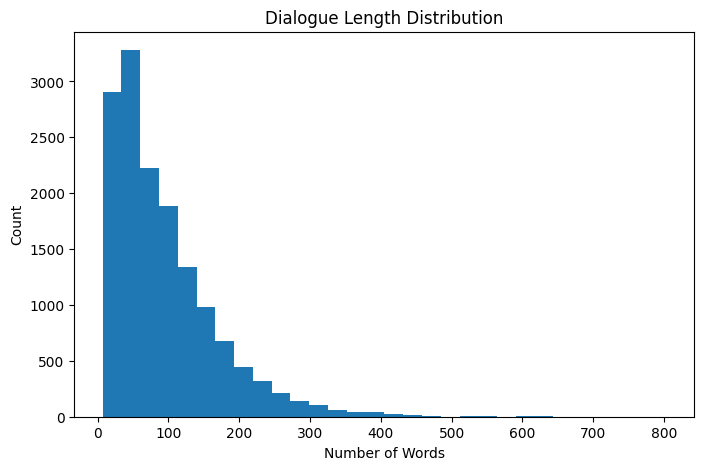

In [64]:
import matplotlib.pyplot as plt

# Visualize the spread of dialogue lengths and identify a long right tail.
plt.figure(figsize=(8,5))
plt.hist(df["dialogue_length"], bins=30)
plt.title("Dialogue Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

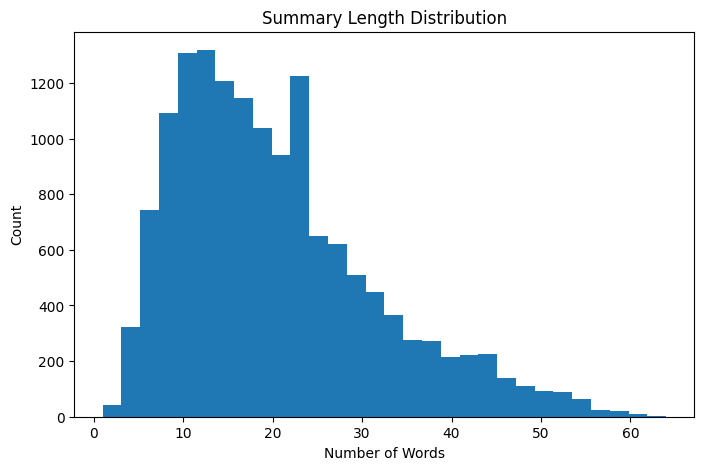

In [65]:
# Summaries should be much shorter than their source dialogues.
plt.figure(figsize=(8,5))
plt.hist(df["summary_length"], bins=30)
plt.title("Summary Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

In [66]:
# Compression ratio: the fraction of source words retained by the reference summary.

df["compression_ratio"] = (
    df["summary_length"] /
    df["dialogue_length"]
)

df["compression_ratio"].describe()

,compression_ratio
count,14731.000000
mean,0.295947
std,0.175506
min,0.015385
25%,0.170213
50%,0.256410
75%,0.379310
max,1.888889


In [67]:
# Inspect the longest dialogue; unusually long examples may require truncation.

df.sort_values(
    "dialogue_length",
    ascending=False
)[["dialogue_length","dialogue","summary"]].head(1)

,dialogue_length,dialogue,summary
4269,803,Ash: Thanks so much! I am feeling so much bett...,Ash is feeling better and he will work on the ...


In [68]:
# Inspect the shortest dialogue to confirm that it still has a meaningful summary.

df.sort_values(
    "dialogue_length"
)[["dialogue_length","dialogue","summary"]].head(1)

,dialogue_length,dialogue,summary
1221,7,Bella: pizza?\nBella: or pasta?\nMick: pizza,Bella and Mick will have pizza.


## 4. Model-specific token analysis

Models do not read whitespace-separated words directly. A tokenizer splits text into model-specific tokens and converts those tokens to IDs. Therefore, the tokenizer used here must match the model selected for fine-tuning.

The earlier BERT token-count cell is retained only as a comparison. The BART token counts below are the values used to choose the BART training input limit.

In [69]:
print(
    "Max dialogue length:",
    df["dialogue_length"].max()
)

print(
    "Average dialogue length:",
    round(df["dialogue_length"].mean(), 2)
)

Max dialogue length: 803
Average dialogue length: 93.79


In [70]:
from collections import Counter

all_words = " ".join(df["dialogue"]).split()

Counter(all_words).most_common(20)

[('I', 37592),
 ('you', 31617),
 ('the', 29897),
 ('to', 28658),
 ('a', 21640),
 ('and', 15311),
 ('it', 14302),
 ('for', 11546),
 ('in', 10723),
 ('of', 10267),
 ('is', 10018),
 ('have', 9612),
 ('be', 8880),
 ('that', 8620),
 ('me', 7769),
 ('but', 7754),
 ('so', 7598),
 ('my', 7348),
 ('are', 7128),
 ("I'm", 7066)]

## 5. Outlier analysis

The interquartile range (IQR) method flags examples far from the middle 50% of the dataset. An outlier is not automatically bad data: these examples are inspected to decide whether they are valid conversations that need a longer input limit or data-quality issues.

In [71]:
# IQR identifies unusually high or low values without assuming a normal distribution.
#def iqr_bounds(series):
    #q1 = series.quantile(0.25)
   # q3 = series.quantile(0.75)
   # iqr = q3 - q1
   ## return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Report outliers for source length, target length, and degree of compression.
#for column in ["dialogue_tokens", "summary_tokens", "compression_ratio"]:
   # lower, upper = iqr_bounds(df[column])
   # outliers = df[(df[column] < lower) | (df[column] > upper)]

   # print(f"\n{column}")
   # print(f"Lower bound: {lower:.2f}")
   # print(f"Upper bound: {upper:.2f}")
   # print(f"Outliers: {len(outliers)} ({len(outliers) / len(df) * 100:.2f}%)")

In [72]:
# Review the five longest model inputs before choosing to truncate or filter them.
#df.nlargest(5, "dialogue_tokens")[
    #["dialogue_tokens", "summary_tokens", "compression_ratio", "dialogue", "summary"]
#]

In [73]:
#for limit in [512, 1024]:
  #  count = (df["dialogue_tokens"] > limit).sum()
   # percent = (count / len(df)) * 100
   # print(f"Over {limit} tokens: {count} dialogues ({percent:.2f}%)")

## EDA Discoveries

- We have a chat dialogue and a summarization of the chat for a messaging app
- 0 Null values, 0 Duplicated values, 14731 samples
- Summary length has a mean length of 20 words , Dialogue length has a mean length of 93 words.
- Mean 29% compression ratio
- There are under 15% of  dialogues that exceed 512 tokens
- 140 dialogues over 512 BART tokens meaning .95% exceeds chosen limit


# 1. Data exploration and preparation

#### Load the SAMSum train, validation, and test splits.



In [74]:
#Load the SAMSum train, validation, and test splits.

splits = {
    "train": "train.csv",
    "validation": "validation.csv",
    "test": "test.csv"
}

train_df = pd.read_csv("hf://datasets/knkarthick/samsum/" + splits["train"])
val_df = pd.read_csv("hf://datasets/knkarthick/samsum/" + splits["validation"])
test_df = pd.read_csv("hf://datasets/knkarthick/samsum/" + splits["test"])

df = train_df.copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (14731, 3)
Validation shape: (818, 3)
Test shape: (819, 3)


In [75]:
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

(14731, 3)
id          0
dialogue    0
summary     0
dtype: int64
0


In [76]:
df["dialogue_length"] = df["dialogue"].apply(
    lambda x: len(x.split())
)

df["dialogue_length"].describe()


,dialogue_length
count,14731.000000
mean,93.792750
std,74.031937
min,7.000000
25%,39.000000
50%,73.000000
75%,128.000000
max,803.000000


In [77]:
df["summary_length"] = df["summary"].apply(
    lambda x: len(x.split())
)

df["summary_length"].describe()

,summary_length
count,14731.000000
mean,20.318444
std,11.153570
min,1.000000
25%,12.000000
50%,18.000000
75%,27.000000
max,64.000000


In [78]:
df["compression_ratio"] = (
    df["summary_length"] /
    df["dialogue_length"]
)

df["compression_ratio"].describe()

,compression_ratio
count,14731.000000
mean,0.295947
std,0.175506
min,0.015385
25%,0.170213
50%,0.256410
75%,0.379310
max,1.888889


## EDA Discoveries

- We have a chat dialogue and a summarization of the chat for a messaging app
- 0 Null values, 0 Duplicated values, 14731 samples
- Summary length has a mean length of 20 words , Dialogue length has a mean length of 93 words.
- Mean 29% compression ratio
- 140 dialogues over 512 BART tokens meaning .95% exceeds chosen limit




### Preprocessing for BERT–GPT-2 Encoder–Decoder Training

In [79]:
from transformers import AutoTokenizer

encoder_tokenizer = AutoTokenizer.from_pretrained(
    "google-bert/bert-base-uncased"
)

decoder_tokenizer = AutoTokenizer.from_pretrained(
    "openai-community/gpt2"
)

# GPT-2 has no default padding token, so use its end-of-text token for padding.
decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

MAX_SOURCE_LENGTH = 512
MAX_TARGET_LENGTH = 128

def preprocess_function(batch):
    # BERT prepares the source dialogue for the encoder.
    model_inputs = encoder_tokenizer(
        batch["dialogue"],
        max_length=MAX_SOURCE_LENGTH,
        truncation=True
    )

    # GPT-2 prepares the reference summary the decoder must learn to generate.
    labels = decoder_tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )

    # Padding should not contribute to training loss.
    labels["input_ids"] = [
        [
            token_id if token_id != decoder_tokenizer.pad_token_id else -100
            for token_id in label_ids
        ]
        for label_ids in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

#### Train

In [80]:
from datasets import Dataset

# Convert pandas DataFrames into Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [81]:
tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

tokenized_val = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

tokenized_test = test_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=test_dataset.column_names
)

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

#### Build a simple baseline


In [82]:
# Simple baseline:
# Use the first 3 dialogue turns as the predicted summary.

def first_turns_baseline(dialogue, num_turns=3):
    turns = dialogue.split("\n")
    first_turns = turns[:num_turns]
    return " ".join(first_turns)


# Apply the baseline to the validation set
val_df["baseline_summary"] = val_df["dialogue"].apply(first_turns_baseline)

# Compare the dialogue, human summary, and baseline summary
val_df[["dialogue", "summary", "baseline_summary"]].head()

,dialogue,summary,baseline_summary
0,"A: Hi Tom, are you busy tomorrow’s afternoon?\...",A will go to the animal shelter tomorrow to ge...,"A: Hi Tom, are you busy tomorrow’s afternoon? ..."
1,Emma: I’ve just fallen in love with this adven...,Emma and Rob love the advent calendar. Lauren ...,Emma: I’ve just fallen in love with this adven...
2,Jackie: Madison is pregnant\nJackie: but she d...,Madison is pregnant but she doesn't want to ta...,Jackie: Madison is pregnant Jackie: but she do...
3,Marla: <file_photo>\nMarla: look what I found ...,Marla found a pair of boxers under her bed.,Marla: <file_photo> Marla: look what I found u...
4,Robert: Hey give me the address of this music ...,Robert wants Fred to send him the address of t...,Robert: Hey give me the address of this music ...


In [83]:
import evaluate

rouge = evaluate.load("rouge")

baseline_results = rouge.compute(
    predictions=val_df["baseline_summary"].tolist(),
    references=val_df["summary"].tolist()
)

baseline_results

{'rouge1': np.float64(0.3138345341386799),
 'rouge2': np.float64(0.09613382104666733),
 'rougeL': np.float64(0.24674605930232035),
 'rougeLsum': np.float64(0.24627684433080888)}

### model architecture/tokenized dataset

In [84]:
from transformers import EncoderDecoderModel, AutoConfig

# Model choices
ENCODER_MODEL = "bert-base-uncased"
DECODER_MODEL = "gpt2"

# Load separate configs so we can tell GPT-2 to behave like a decoder
encoder_config = AutoConfig.from_pretrained(ENCODER_MODEL)

decoder_config = AutoConfig.from_pretrained(DECODER_MODEL)
decoder_config.is_decoder = True
decoder_config.add_cross_attention = True

# Build encoder-decoder architecture:
# BERT reads/understands the dialogue.
# GPT-2 generates the summary one token at a time.
model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    ENCODER_MODEL,
    DECODER_MODEL,
    encoder_config=encoder_config,
    decoder_config=decoder_config
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: gpt2
Key                                                 | Status  | 
----------------------------------------------------+---------+-
transformer.h.{0...11}.ln_cross_attn.weight         | MISSING | 
transformer.h.{0...11}.crossattention.c_proj.weight | MISSING | 
transformer.h.{0...11}.ln_cross_attn.bias           | MISSING | 
transformer.h.{0...11}.crossattention.q_attn.bias   | MISSING | 
transformer.h.{0...11}.crossattention.c_attn.bias   | MISSING | 
transformer.h.{0...11}.crossattention.c_attn.weight | MISSING | 
transformer.h.{0...11}.crossattention.q_attn.weight | MISSING | 
transformer.h.{0...11}.crossattention.c_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [85]:
# GPT-2 does not have a normal padding token.
# We use GPT-2's end-of-text token as the padding token.
decoder_tokenizer.pad_token = decoder_tokenizer.eos_token

# Tell the model which tokens control generation.
model.config.decoder_start_token_id = decoder_tokenizer.bos_token_id
model.config.eos_token_id = decoder_tokenizer.eos_token_id
model.config.pad_token_id = decoder_tokenizer.pad_token_id

# The model's output vocabulary should match GPT-2's tokenizer.
model.config.vocab_size = model.config.decoder.vocab_size

# Generation settings for summaries
# model.config.max_length = 128  # Removed to fix ValueError
# model.config.min_length = 10   # Removed to fix ValueError
# model.config.no_repeat_ngram_size = 3 # Removed to fix ValueError
# model.config.early_stopping = True    # Removed to fix ValueError
# model.config.length_penalty = 2.0     # Removed to fix ValueError
# model.config.num_beams = 4            # Removed to fix ValueError

model.generation_config.max_length = 128
model.generation_config.min_length = 10
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.early_stopping = True
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4

In [86]:
print("Encoder:", model.config.encoder.model_type)
print("Decoder:", model.config.decoder.model_type)
print("Decoder start token ID:", model.config.decoder_start_token_id)
print("EOS token ID:", model.config.eos_token_id)
print("PAD token ID:", model.config.pad_token_id)

Encoder: bert
Decoder: gpt2
Decoder start token ID: 50256
EOS token ID: 50256
PAD token ID: 50256


In [87]:
import evaluate
import numpy as np

rouge = evaluate.load("rouge")

### Train and optimize


This section fine-tunes the BERT-GPT2 encoder-decoder model. The model learns by comparing GPT-2's generated summary tokens against the human summary labels. Hugging Face's `Seq2SeqTrainer` handles the training loop, cross-entropy loss, optimizer steps, validation checks, checkpointing, and progress logging.

In [88]:
def compute_metrics(eval_pred):
    """Calculate ROUGE scores during validation.

    The trainer returns generated token IDs and label token IDs.
    We decode both back into text, then compare generated summaries
    against the human reference summaries.
    """
    predictions, labels = eval_pred

    # Some trainer versions return predictions inside a tuple.
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    decoded_preds = decoder_tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    # Labels use -100 for padding so the loss ignores padded positions.
    # The tokenizer cannot decode -100, so we replace it with the pad token ID.
    labels = np.where(
        labels != -100,
        labels,
        decoder_tokenizer.pad_token_id
    )

    decoded_labels = decoder_tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    results = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {
        "rouge1": results["rouge1"],
        "rouge2": results["rouge2"],
        "rougeL": results["rougeL"],
        "rougeLsum": results["rougeLsum"]
    }


In [89]:
import torch

# Small batches help avoid memory crashes, especially on a laptop.
# Gradient accumulation lets the model behave like it saw a larger batch.
TRAIN_BATCH_SIZE = 2
EVAL_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 5e-5
NUM_EPOCHS = 3

# Use mixed precision only on CUDA GPUs. This saves memory and can speed up training.
USE_FP16 = torch.cuda.is_available()

print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)
print("Effective train batch size:", TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)


CUDA available: True
MPS available: False
Effective train batch size: 8


In [90]:
# Make sure the model and decoder know the special token IDs before training.
# GPT-2 uses the same end-of-text token for start/end/padding in this setup.
model.config.decoder_start_token_id = decoder_tokenizer.bos_token_id or decoder_tokenizer.eos_token_id
model.config.eos_token_id = decoder_tokenizer.eos_token_id
model.config.pad_token_id = decoder_tokenizer.pad_token_id
model.config.decoder.pad_token_id = decoder_tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# Generation settings used during validation and later inference.
# These should now be set on model.generation_config instead of model.config
model.generation_config.max_length = MAX_TARGET_LENGTH
model.generation_config.min_length = 10
model.generation_config.no_repeat_ngram_size = 3
model.generation_config.length_penalty = 2.0
model.generation_config.num_beams = 4
model.generation_config.early_stopping = True

print("Decoder start token:", model.config.decoder_start_token_id)
print("EOS token:", model.config.eos_token_id)
print("PAD token:", model.config.pad_token_id)

Decoder start token: 50256
EOS token: 50256
PAD token: 50256


In [91]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, DataCollatorForSeq2Seq, EarlyStoppingCallback
import inspect

# Newer Transformers versions use eval_strategy; older versions use evaluation_strategy.
training_arg_names = inspect.signature(Seq2SeqTrainingArguments.__init__).parameters
eval_strategy_name = "eval_strategy" if "eval_strategy" in training_arg_names else "evaluation_strategy"

training_kwargs = {
    "output_dir": "./bert-gpt2-dialogue-summarizer",

    # Optimization parameters
    "learning_rate": LEARNING_RATE,
    "per_device_train_batch_size": TRAIN_BATCH_SIZE,
    "per_device_eval_batch_size": EVAL_BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_train_epochs": NUM_EPOCHS,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,

    # Validation, checkpointing, and model selection
    eval_strategy_name: "epoch",
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "rougeL",
    "greater_is_better": True,
    "save_total_limit": 2,

    # Generate summaries during validation so ROUGE can be calculated
    "predict_with_generate": True,
    "generation_max_length": MAX_TARGET_LENGTH,
    "generation_num_beams": 4,

    # Progress monitoring and resource management
    "logging_steps": 100,
    "report_to": "none",
    "fp16": USE_FP16,
    "dataloader_num_workers": 0
}

training_args = Seq2SeqTrainingArguments(**training_kwargs)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [92]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=encoder_tokenizer,
    model=model,
    label_pad_token_id=-100
)

class SafeSeq2SeqTrainer(Seq2SeqTrainer):
    """Trainer fix for this Transformers/BERT version mismatch.

    The current Trainer may pass `num_items_in_batch` into the model.
    BERT does not accept that argument, so this removes it before the
    normal seq2seq loss calculation runs.
    """
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        inputs.pop("num_items_in_batch", None)
        return super().compute_loss(
            model,
            inputs,
            return_outputs=return_outputs
        )


# SafeSeq2SeqTrainer implements the training loop.
# Loss function: the model automatically uses cross-entropy loss because labels are provided.
# Early stopping stops training if validation ROUGE-L does not improve after 2 evaluations.
trainer = SafeSeq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [ ]:
# Start fine-tuning.
# The trainer will log training loss, run validation each epoch, compute ROUGE,
# save checkpoints, and keep the best checkpoint based on validation ROUGE-L.
train_result = trainer.train()

train_result


/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no 

Epoch,Training Loss,Validation Loss


/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:443: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no 

In [ ]:
# Save the best model and both tokenizers for later evaluation/inference.
BEST_MODEL_DIR = "./best-bert-gpt2-summarizer"

trainer.save_model(BEST_MODEL_DIR)
encoder_tokenizer.save_pretrained(f"{BEST_MODEL_DIR}/encoder_tokenizer")
decoder_tokenizer.save_pretrained(f"{BEST_MODEL_DIR}/decoder_tokenizer")

print("Best model saved to:", BEST_MODEL_DIR)
